In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [3]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")
print(X.head())
print(y.head())

print(X.shape)
print(y.value_counts())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [4]:
y = y.map({
    0: "Malignant",
    1: "Benign"
})
print(y.value_counts())
y = y.map({
    "Malignant": 0,
    "Benign": 1
})

target
Benign       357
Malignant    212
Name: count, dtype: int64


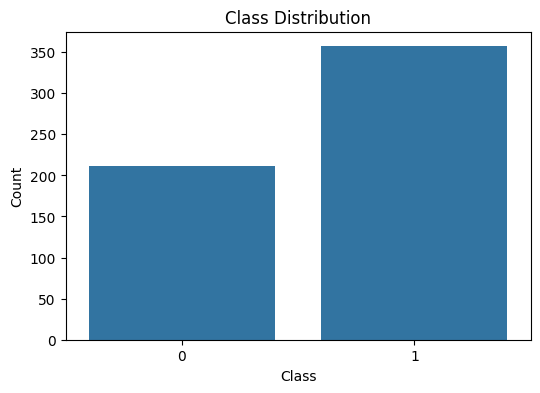

In [5]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

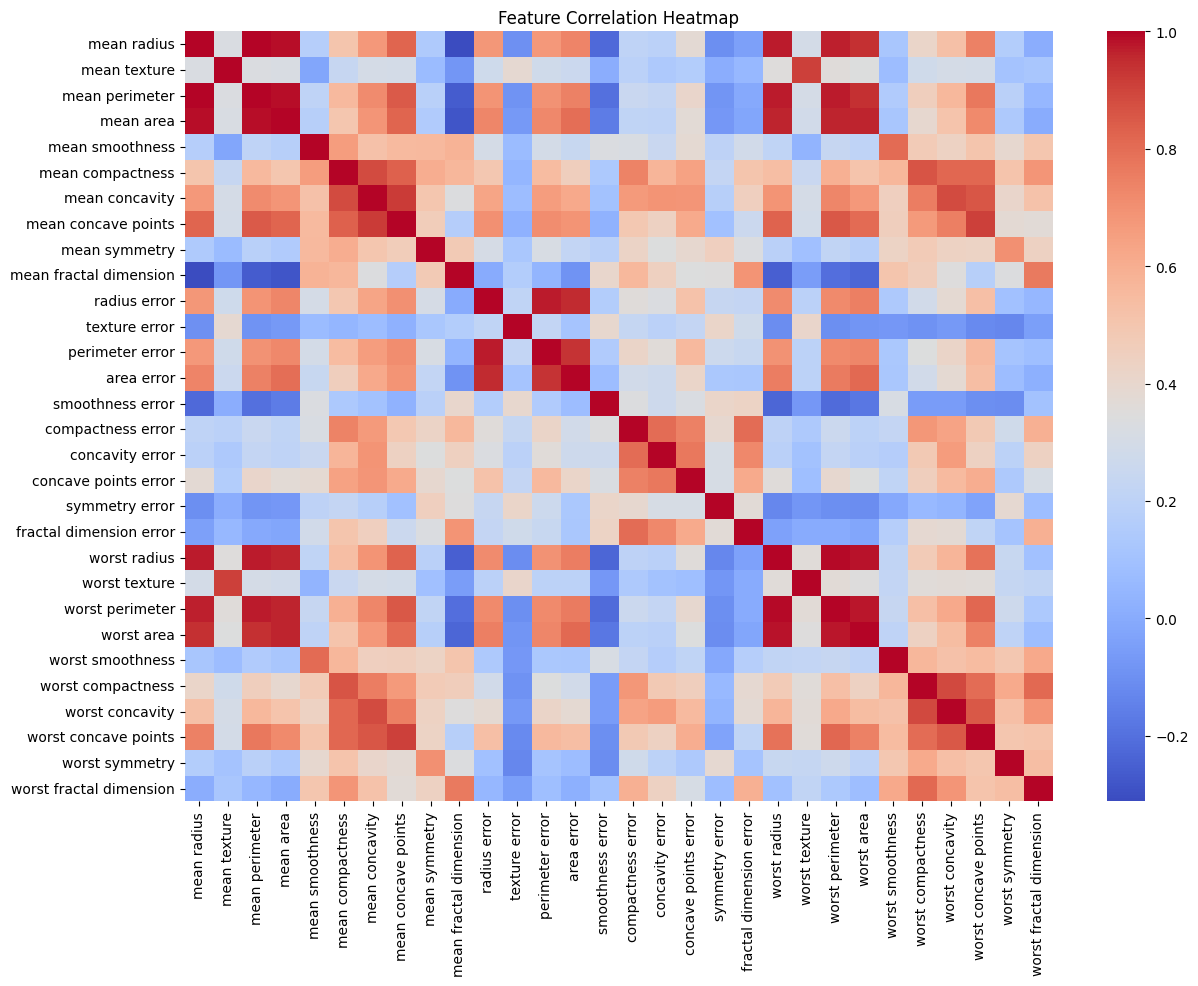

In [6]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [8]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.9122807017543859


In [9]:
dt_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)
print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

print("Best CV Accuracy:")
print(dt_grid.best_score_)

Best Decision Tree Parameters:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV Accuracy:
0.9384615384615385


In [10]:
best_dt = dt_grid.best_estimator_

y_pred_dt = best_dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("Precision:", precision_score(y_test, y_pred_dt))

print("Recall:", recall_score(y_test, y_pred_dt))

print("F1 Score:", f1_score(y_test, y_pred_dt))
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

Accuracy: 0.9210526315789473
Precision: 0.9565217391304348
Recall: 0.9166666666666666
F1 Score: 0.9361702127659575
[[39  3]
 [ 6 66]]


In [11]:
rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, None],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("Best CV Accuracy:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'bootstrap': False, 'max_depth': None, 'max_features': 'log2', 'n_estimators': 100}
Best CV Accuracy:
0.9692307692307693


In [12]:
best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104
Confusion Matrix:
[[39  3]
 [ 2 70]]


Decision Tree AUC: 0.9163359788359788
Random Forest AUC: 0.994378306878307


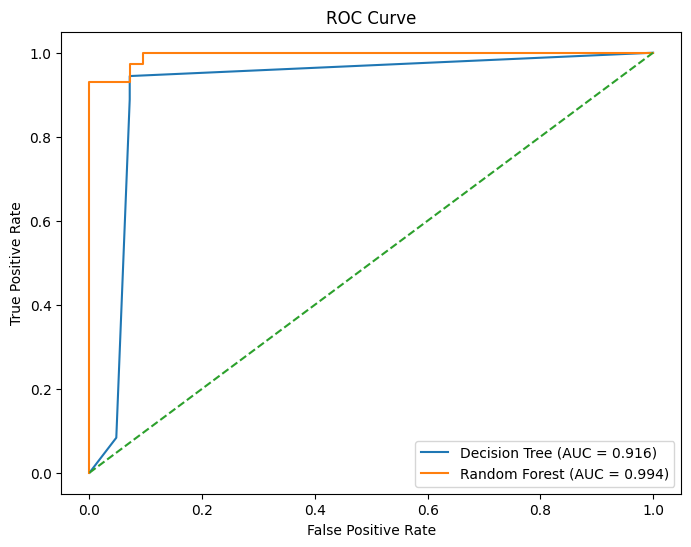

In [13]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Decision Tree
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

# Random Forest
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Decision Tree AUC:", auc_dt)
print("Random Forest AUC:", auc_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

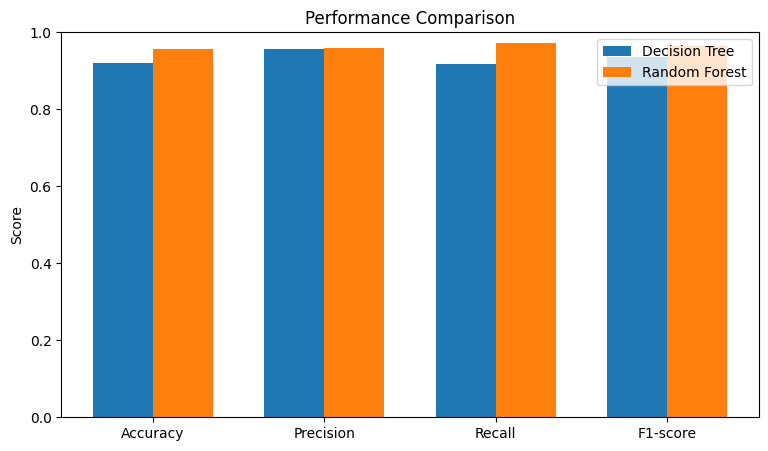

In [15]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

dt_scores = [
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt)
]

rf_scores = [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, dt_scores, width, label="Decision Tree")
plt.bar(x + width/2, rf_scores, width, label="Random Forest")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Performance Comparison")
plt.ylim(0, 1)
plt.legend()

plt.show()

In [16]:
# Feature Importance - Decision Tree

dt_importance = pd.Series(
    best_dt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(dt_importance)

worst radius               0.718940
worst concave points       0.119597
texture error              0.054255
worst texture              0.043286
worst concavity            0.016819
worst smoothness           0.013062
area error                 0.012451
worst symmetry             0.011058
worst area                 0.008708
smoothness error           0.001824
mean perimeter             0.000000
mean area                  0.000000
mean radius                0.000000
mean texture               0.000000
perimeter error            0.000000
radius error               0.000000
mean symmetry              0.000000
mean fractal dimension     0.000000
mean concave points        0.000000
mean concavity             0.000000
mean smoothness            0.000000
mean compactness           0.000000
symmetry error             0.000000
fractal dimension error    0.000000
concavity error            0.000000
concave points error       0.000000
compactness error          0.000000
worst perimeter            0

In [17]:
# Feature Importance - Random Forest

rf_importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(rf_importance)

worst area                 0.128615
worst concave points       0.120391
worst radius               0.110227
mean perimeter             0.099158
mean area                  0.070356
mean concavity             0.059521
worst perimeter            0.058613
mean concave points        0.057880
mean radius                0.047103
area error                 0.027597
worst concavity            0.027198
worst compactness          0.023838
worst texture              0.019413
worst smoothness           0.018093
mean compactness           0.013654
mean texture               0.013072
concavity error            0.012845
radius error               0.012642
perimeter error            0.012386
worst symmetry             0.009431
mean smoothness            0.008067
fractal dimension error    0.007470
worst fractal dimension    0.007436
texture error              0.005983
smoothness error           0.005888
compactness error          0.005607
symmetry error             0.004906
concave points error       0

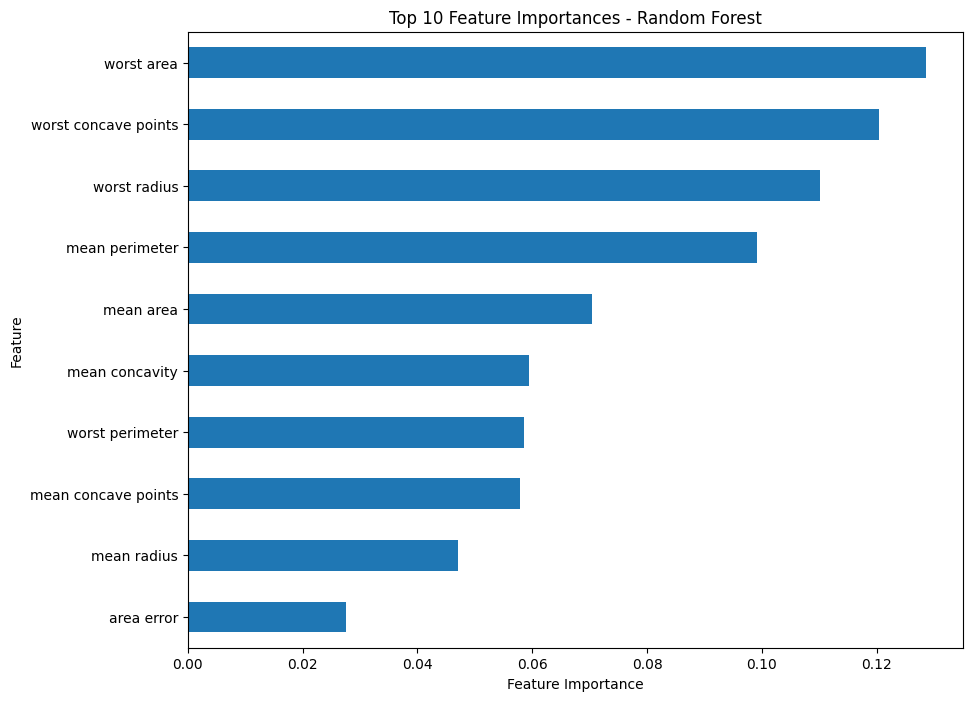

In [18]:
plt.figure(figsize=(10, 8))

rf_importance.head(10).sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Random Forest")

plt.show()